In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from utils import *
from genData import *
from model.unet import Attention_UNet

# Set random seeds for reproducibility
np.random.seed(1)
torch.manual_seed(1)

# Constants
f0 = 20
det = 'H1L1'

Tsft = 14400
max_train_levels = [40.28]
tobs = [32, 64, 96, 128]
train_level_level = [32, 32, 32, 40]
time_list = [5, 10, 16, 21]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def compute_detection_statistic(images, method='mean'):
    valid_methods = {'mean', 'mean_sq'}
    if method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}, got {method}")
    images_np = np.abs(images)
    if method == 'mean':
        return np.mean(images_np.transpose(0, 2, 3, 1), axis=(1, 2, 3))
    elif method == 'mean_sq':
        return np.mean(np.square(images_np.transpose(0, 2, 3, 1)), axis=(1, 2, 3))


# Compute pdet for each frequency
pdet_values = []
for (t, train_level, time) in zip(tobs, train_level_level, time_list):
    size = (512, t)
    # Initialize model and load weights
    model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
    version = f'H1L1_a1b1_20Hz_D{train_level}-{train_level}_T{time}_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x{t}_MSELoss_dropout0'
    model.load_state_dict(torch.load(f"../trained_model/20Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False))
    model.eval()


    # Load validation data
    filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{t}_{Tsft}s_4c_traindata_n1000_seed4.npz'
    targets = np.load(filename, allow_pickle=True)['clean_image']
    masks = new_mask(normalize(targets))

    # Generate signal data
    data = []
    mask_data = []
    target_data = []
    label_data = []
    for Sn in max_train_levels:
        noise = np.empty((targets.shape[0],) + size + (4,))
        for i in range(noise.shape[0]):
            noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
        data.append(normalize(noise + targets))
        mask_data.append(masks)
        target_data.append(normalize(targets))
        labels = [Sn] * noise.shape[0]
        label_data.append(labels)

    data = np.concatenate(data)
    mask_data = np.concatenate(mask_data)
    target_data = np.concatenate(target_data)
    label_data = np.concatenate(label_data)
    data = load_signal_datasetv2(data, target_data, mask_data, label_data)

    # Generate noise data
    noise = np.empty((1000,) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
    noise = normalize(noise)
    noise_data = load_noise_dataset(noise)

    # Create data loader
    val_loader = make_data_loader([data, noise_data], batch_size=8, shuffle=False)

    # Run inference
    inputs = []
    predictions = []
    ground_truth = []
    masks = []
    labels = []
    with torch.no_grad():
        for test_batch in tqdm(val_loader, desc=f'Evaluating {f0}Hz'):
            test_images, test_targets, test_masks, test_labels = test_batch
            test_images = test_images.to(device)
            test_targets = test_targets.to(device)
            test_masks = test_masks.to(device)
            test_labels = test_labels.to(device)
            outputs = model(test_images)
            inputs.append(test_images.cpu().numpy())
            predictions.append(outputs.cpu().numpy())
            ground_truth.append(test_targets.cpu().numpy())
            masks.append(test_masks.cpu().numpy())
            labels.append(test_labels.cpu().numpy())

    inputs = np.concatenate(inputs, axis=0)
    predictions = np.concatenate(predictions, axis=0)
    ground_truth = np.concatenate(ground_truth, axis=0)
    masks = np.concatenate(masks, axis=0)
    labels = np.concatenate(labels, axis=0)

    # Compute detection statistics
    results_dict = {}
    unique_labels = np.unique(labels)
    for label in unique_labels:
        indices = np.where(labels == label)[0]
        results_dict[label] = compute_detection_statistic(predictions[indices], method='mean_sq')

    # Compute x_pfa from noise (label=np.inf)
    x_pfa = np.percentile(results_dict[np.inf], (1-0.71/100)*100) if np.inf in results_dict else np.percentile(results_dict[max_train_levels[0]], (1-0.71/100)*100)

    # Compute pdet
    mask_dict = {}
    for key in results_dict.keys():
        data = results_dict[key]
        mask = data > x_pfa
        mask_dict[key] = mask
        if key != np.inf:
            pdet = mask.sum() / data.size
            pdet_values.append(pdet)


Evaluating 20Hz: 100%|██████████| 250/250 [00:23<00:00, 10.79it/s]


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import interp1d
from utils import *
from genData import *
from model.unet import Attention_UNet

# Matplotlib configuration
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 20,
    'axes.linewidth': 1,
    'axes.labelweight': 'normal',
    'mathtext.fontset': 'cm'
})

# Set random seeds for reproducibility
np.random.seed(111)
torch.manual_seed(111)

# Constants
f0 = 20
det = 'H1L1'
Tsft = 14400
tobs = [32, 64, 96, 128]
train_level_level = [32, 32, 32, 40]
time_list = [5, 10, 16, 21]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_dataset(images, batch_size=8, shuffle=True):

    # Convert to torch tensors
    images_tensor = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
    dataset = TensorDataset(images_tensor)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return data_loader

def compute_detection_statistic(images, method='mean_sq'):
    """
    Compute detection statistic for images.
    """
    valid_methods = {'mean', 'mean_sq'}
    if method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}, got {method}")
    images_np = np.abs(images)
    if method == 'mean':
        return np.mean(images_np.transpose(0, 2, 3, 1), axis=(1, 2, 3))
    elif method == 'mean_sq':
        return np.mean(np.square(images_np.transpose(0, 2, 3, 1)), axis=(1, 2, 3))

# Compute depth at 90% detection for each Tobs
results = {}
depth_values = []
for t, train_level, time in zip(tobs, train_level_level, time_list):

    if t == 32:
        Sn_values = np.linspace(23, 28, 5)  # Range of Sn values
    if t== 64:
        Sn_values = np.linspace(28, 33, 5)  # Range of Sn values
    if t== 96:
        Sn_values = np.linspace(32, 37, 5)  # Range of Sn values
    if t== 128:
        Sn_values = np.linspace(33, 38, 5)  # Range of Sn values

    size = (512, t)
    # Initialize model and load weights
    model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
    version = f'H1L1_a1b1_20Hz_D{train_level}-{train_level}_T{time}_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x{t}_MSELoss_dropout0'
    try:
        model.load_state_dict(torch.load(f"../trained_model/20Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False))
    except FileNotFoundError:
        print(f"Warning: Model file for Tobs={t} not found. Setting depth to NaN.")
        depth_values.append(np.nan)
        continue
    model.eval()

    # Load validation data
    filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{t}_{Tsft}s_4c_traindata_n1000_seed4.npz'
    try:
        targets = np.load(filename, allow_pickle=True)['clean_image']
    except FileNotFoundError:
        print(f"Warning: Validation data for Tobs={t} not found. Setting depth to NaN.")
        depth_values.append(np.nan)
        continue

    # Compute x_pfa from pure noise once
    noise = np.empty((1000,) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
    noise = normalize(noise)
    noise_loader = load_dataset(noise, batch_size=8, shuffle=False)
    noise_stats = []
    with torch.no_grad():
        for images, in tqdm(noise_loader, desc=f"Computing x_pfa for Tobs={t}"):
            images = images.to(device)
            outputs = model(images)
            stats = compute_detection_statistic(outputs.cpu().numpy(), method='mean_sq')
            noise_stats.append(stats)
    noise_stats = np.concatenate(noise_stats)
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)

    # Compute pdet for each Sn
    pdet_per_sn = []
    for Sn in Sn_values:
        # Generate signal data
        noise = np.empty((targets.shape[0],) + size + (4,))
        for i in range(noise.shape[0]):
            noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
        data = normalize(noise + targets)
        data_loader = load_dataset(data, batch_size=8, shuffle=False)

        # Compute detection statistics
        stats = []
        with torch.no_grad():
            for images, in tqdm(data_loader, desc=f'Evaluating Tobs={t}, Sn={Sn:.2f}'):
                images = images.to(device)
                outputs = model(images)
                batch_stats = compute_detection_statistic(outputs.cpu().numpy(), method='mean_sq')
                stats.append(batch_stats)
        stats = np.concatenate(stats)

        # Compute pdet
        mask = stats > x_pfa
        pdet = mask.sum() / stats.size
        pdet_per_sn.append(pdet)

    # Interpolate to find depth at pdet = 0.9
    result_dict = {'pdet_per_sn': pdet_per_sn, 'Sn_values': Sn_values.tolist()}
    try:
        # Sort by pdet to ensure monotonicity for interpolation
        sort_idx = np.argsort(pdet_per_sn)[::-1]  # Descending order
        pdet_sorted = np.array(pdet_per_sn)[sort_idx]
        sn_sorted = Sn_values[sort_idx]
        # Check if pdet=0.9 is within the range of pdet_sorted
        if pdet_sorted.min() > 0.9 or pdet_sorted.max() < 0.9:
            raise ValueError("pdet=0.9 is outside the range of pdet values")
        depth_at_90 = np.interp(0.9, pdet_sorted[::-1], sn_sorted[::-1])  # Reverse for decreasing pdet
        depth_values.append(depth_at_90)
        result_dict['pdet_sorted'] = pdet_sorted.tolist()
        result_dict['sn_sorted'] = sn_sorted.tolist()
        result_dict['depth_at_90'] = float(depth_at_90)
    except ValueError as e:
        print(f"Warning: Interpolation failed for Tobs={t} ({e}). Setting depth to NaN.")
        depth_values.append(np.nan)
        result_dict['pdet_sorted'] = []
        result_dict['sn_sorted'] = []
        result_dict['depth_at_90'] = np.nan
    results[f'Tobs_{t}'] = result_dict

# Save all numbers to a .npz file
np.savez('./depth_interpolation_results.npz', **results)


25-08-06 02:08:45.162 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
Evaluating Tobs=128, Sn=38.00: 100%|██████████| 125/125 [00:11<00:00, 11.02it/s]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import interp1d
from model.unet import Attention_UNet

# Matplotlib configuration
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 25,
    'axes.linewidth': 1,
    'axes.labelweight': 'normal',
    'mathtext.fontset': 'cm'
})

# Set random seeds for reproducibility
np.random.seed(0)

In [3]:
data = np.load('./depth_interpolation_results.npz', allow_pickle=True)

In [4]:
# Linear interpolation for decreasing y
def interpolate_x(y_target, x, y):
    return np.interp(y_target, y[::-1], x[::-1])

# Estimate second derivative locally
def estimate_second_derivative(x, y, idx):
    h = np.diff(x)
    h_avg = np.mean(h) if not np.allclose(h, h[0]) else h[0]
    # Use points around the interpolation interval (idx-1, idx)
    print(idx)
    if idx >= 1 and idx < len(y) - 1:
        # Central difference at x[idx-1] or x[idx]
        deriv2 = (y[idx+1] - 2*y[idx] + y[idx-1]) / (h_avg**2)
        return abs(deriv2)
    elif idx == 0 and len(y) >= 3:
        # Forward difference at x[0]
        deriv2 = (y[2] - 2*y[1] + y[0]) / (h_avg**2)
        return abs(deriv2)
    elif idx == len(y) - 1 and len(y) >= 3:
        # Backward difference at x[-1]
        deriv2 = (y[-1] - 2*y[-2] + y[-3]) / (h_avg**2)
        return abs(deriv2)
    return 1.0  # Fallback if insufficient points

# Error estimation
def interpolation_error(y_target, x, y, dy):
    idx = np.searchsorted(y[::-1], y_target, side='right')
    if idx == 0 or idx == len(y):
        raise ValueError("y_target is outside the range of y-values")
    # Adjust indices for decreasing y
    idx = len(y) - idx  # Convert to original array index
    x0, x1 = x[idx-1], x[idx]
    y0, y1 = y[idx-1], y[idx]
    dy0, dy1 = dy[idx-1], dy[idx]
    h = x1 - x0
    
    # Interpolated x
    x_interp = np.interp(y_target, y[::-1], x[::-1])
    
    # Interpolation error
    second_derivative = estimate_second_derivative(x, y, idx)
    y_interp_error = (1/8) * h**2 * second_derivative
    
    # Slope of the interpolated line
    slope = (y1 - y0) / (x1 - x0)
    
    # Propagate dy uncertainty to x
    t = (y_target - y0) / (y1 - y0)
    y_uncertainty = np.sqrt((1-t)**2 * dy0**2 + t**2 * dy1**2)
    
    # Total x-error
    x_error = np.sqrt((y_interp_error / abs(slope))**2 + (y_uncertainty / abs(slope))**2)
    
    return x_interp, x_error

In [5]:
def binomialError(y, n):
    err =  np.sqrt(y*(1.-y)/n)
    err[err==0] = 1./n
    return err

tobs = [32, 64, 96, 128]

D90 = []
D90_err = []
for t in tobs:
    pdet = data[f'Tobs_{t}'].item()['pdet_per_sn']
    depth = data[f'Tobs_{t}'].item()['Sn_values']

    pdet = np.array(pdet)
    depth = np.array(depth)
    dpdet = binomialError(pdet, 1000)

    # Compute interpolation and error
    x, x_error = interpolation_error(0.9, depth, pdet, dpdet)
    D90.append(x)
    D90_err.append(x_error)
    
D90 = np.array(D90)
D90_Err = np.array(D90_err)

2
3
2
3


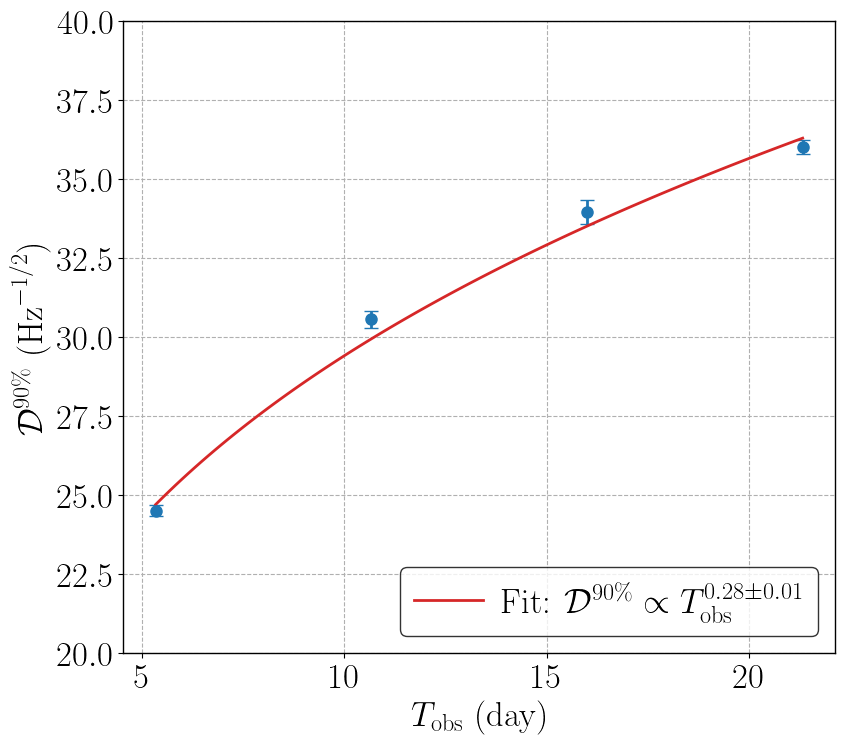

In [7]:
# Define the power law function
from scipy.optimize import curve_fit
def power_law(tobs_normalized, k, a):
    return k * (tobs_normalized ** a)

# Normalize tobs
tobs_normalized = np.array(tobs) / 32

# Fit the power law with errors
popt, pcov = curve_fit(power_law, tobs_normalized, D90, p0=[1.3, 0.1], sigma=D90_err, absolute_sigma=True)
k, a = popt
k_err, a_err = np.sqrt(np.diag(pcov))

# Plot
fig, ax = plt.subplots(figsize=(9, 8))

tobs_days = np.array(tobs) / 6
ax.errorbar(tobs_days, D90, yerr=D90_err, fmt='o', color='tab:blue', 
            linewidth=2, markersize=8, capsize=5)

# Generate fitted curve
tobs_fit = np.linspace(32, 128, 100)
tobs_fit_days = tobs_fit / 6
tobs_normalized_fit = tobs_fit / 32
depth_fit = power_law(tobs_normalized_fit, k, a)
ax.plot(tobs_fit_days, depth_fit, linestyle='-', color='tab:red', 
        linewidth=2, label=f'Fit: $\\mathcal{{D}}^{{90\\%}} \\propto T_\\mathrm{{obs}}^{{{a:.2f} \\pm {a_err:.2f}}}$')
# Axis labels and styling
ax.set_xlabel(r'$T_{\mathrm{obs}}$ (day)')
ax.set_ylabel(r'$\mathcal{D}^{90\%}\; (\mathrm{Hz}^{-1/2})$')
ax.set_xticks([5, 10, 15, 20])  # Ticks at 5, 10, 15, 20 days

ax.legend(loc=4, markerscale=2, handlelength=2, handletextpad=0.5, edgecolor='k')
ax.grid(True, which='major', linestyle='dashed')
ax.set_ylim(20, 40)

# Save figure
plt.tight_layout()
plt.savefig('../result/plots/depth_vs_tobs.pdf', dpi=300, bbox_inches='tight')

# implement the error on depth, use lower and upper bound to do interp1d and get Depth90 and plot the fit 